# FarmTech Solutions | Fase 5
## Machine Learning e Computação em Nuvem aplicados à previsão de rendimento agrícola

**Curso:** Tecnologia em Inteligência Artificial | FIAP

**Integrantes:** Karina Garta Szewczuk (RM569309), Maria Sabrina Feitosa da Silva (RM568714), Nicolas Lima Apolinário (RM570741) e Roger Gabriel de Souza Jesus Costa (RM573659).

## 1. Contexto e objetivo

A FarmTech Solutions presta serviços de Inteligência Artificial para uma fazenda de médio porte, com aproximadamente 200 hectares e diferentes culturas agrícolas.

Nesta fase, usamos a base `crop_yield.csv`, que reúne precipitação, umidade específica, umidade relativa, temperatura e rendimento. O trabalho começa com uma análise exploratória para entender o comportamento dos dados. Depois, usamos clusterização para procurar padrões de produtividade e possíveis valores discrepantes. Por fim, treinamos cinco algoritmos de regressão e comparamos o desempenho de cada um na previsão do rendimento da safra.

Durante a modelagem, também aplicamos pré-processamento, validação cruzada e métricas de avaliação para não depender de um único resultado de teste.


In [1]:
# Bibliotecas e configurações iniciais
# Nesta célula importamos todas as bibliotecas que serão usadas ao longo do projeto.
# Cada grupo tem uma função diferente: leitura de dados, gráficos,
# pré-processamento, clusterização e modelos de Machine Learning.

# Biblioteca nativa do Python usada aqui para criar/verificar pastas.
import os

# NumPy: operações numéricas e matemáticas.
import numpy as np

# Pandas: leitura, organização e análise da base de dados em formato de tabela.
import pandas as pd

# Matplotlib e Seaborn: criação dos gráficos utilizados na análise exploratória.
import matplotlib.pyplot as plt
import seaborn as sns

# Ferramentas do scikit-learn para separar e validar os dados
# train_test_split: divide a base em treino e teste.
# cross_validate: executa validação cruzada e calcula várias métricas.
# KFold: define como os dados serão divididos durante a validação cruzada.
from sklearn.model_selection import train_test_split, cross_validate, KFold

# StandardScaler: coloca variáveis numéricas em uma escala comparável.
# OneHotEncoder: transforma a variável categórica "Crop" em colunas numéricas.
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ColumnTransformer: aplica transformações diferentes em tipos de colunas diferentes.
from sklearn.compose import ColumnTransformer

# Pipeline: encadeia pré-processamento e modelo, reduzindo etapas manuais
# e ajudando a evitar vazamento de dados.
from sklearn.pipeline import Pipeline

# KMeans: algoritmo de aprendizado não supervisionado usado para clusterização.
from sklearn.cluster import KMeans

# PCA: reduz várias dimensões para 2 componentes, facilitando a visualização.
from sklearn.decomposition import PCA

# Métricas de clusterização e regressão.
from sklearn.metrics import (
    silhouette_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Cinco algoritmos de regressão que serão comparados
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

# Faz com que os gráficos apareçam dentro do próprio notebook.
%matplotlib inline

# Cria a pasta "assets" caso ela ainda não exista.
# Essa pasta recebe os gráficos gerados pelo notebook.
os.makedirs("assets", exist_ok=True)

# Define um tema visual padrão para os gráficos.
sns.set_theme(style="whitegrid")

# Fixa a aleatoriedade para que os resultados sejam reproduzíveis.
RANDOM_STATE = 42


## 2. Carga e primeira inspeção dos dados


In [2]:
# Leitura da base de dados
# Lê o arquivo CSV e guarda a tabela na variável "df".
# O arquivo crop_yield.csv precisa estar na mesma pasta do notebook.
df = pd.read_csv("crop_yield.csv")

# Exibe o tamanho da base.
# df.shape retorna (quantidade de linhas, quantidade de colunas).
print(f"Formato do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")

# Mostra as 5 primeiras linhas para uma inspeção inicial.
df.head()


Formato do dataset: 156 linhas x 6 colunas


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [3]:
# Conferência da estrutura dos dados
# df.info() mostra os nomes das colunas, os tipos de dados, a quantidade de valores preenchidos e o uso de memória.
# Essa checagem ajuda a identificar colunas com tipos errados
# ou possíveis valores ausentes antes das análises.
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    str    
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 9.4 KB


In [4]:
# Conferência de valores ausentes e duplicados
print("Valores ausentes por coluna:")

# isnull() marca células vazias como True.
# sum() conta quantos valores ausentes existem em cada coluna.
print(df.isnull().sum())

# duplicated() identifica linhas totalmente repetidas.
# sum() conta quantas duplicatas existem.
print(f"\nLinhas duplicadas: {df.duplicated().sum()}")


Valores ausentes por coluna:
Crop                                    0
Precipitation (mm day-1)                0
Specific Humidity at 2 Meters (g/kg)    0
Relative Humidity at 2 Meters (%)       0
Temperature at 2 Meters (C)             0
Yield                                   0
dtype: int64

Linhas duplicadas: 0


## 3. Análise exploratória (EDA)

### 3.1 Distribuição das culturas e do rendimento


In [5]:
# Distribuição das culturas e estatísticas descritivas
# Conta quantos registros existem para cada cultura.
# Isso ajuda a verificar se a base está balanceada.
print(df["Crop"].value_counts())

print()

# describe() calcula estatísticas das colunas numéricas:
# média, desvio-padrão, mínimo, máximo e quartis.
df.describe()


Crop
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39
Name: count, dtype: int64



,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


In [6]:
# Verificação das condições climáticas repetidas
# Como existem 39 registros por cultura, verificamos se a mesma
# sequência climática foi reutilizada entre todas elas.

# Lista com as quatro variáveis climáticas.
climaticas = [
    "Precipitation (mm day-1)",
    "Specific Humidity at 2 Meters (g/kg)",
    "Relative Humidity at 2 Meters (%)",
    "Temperature at 2 Meters (C)"
]

# Separa os dados por cultura e mantém apenas as variáveis climáticas.
# reset_index(drop=True) reinicia o índice para permitir comparação linha a linha.
grupos = {
    crop: grupo[climaticas].reset_index(drop=True)
    for crop, grupo in df.groupby("Crop")
}

# Lista com os nomes das culturas encontradas.
culturas = list(grupos.keys())

# Usa a primeira cultura como referência.
base = grupos[culturas[0]]

# Compara as demais culturas com a primeira.
climas_identicos = all(
    grupos[cultura].equals(base)
    for cultura in culturas[1:]
)

print(
    f"As {len(culturas)} culturas compartilham exatamente "
    f"a mesma série de 39 leituras climáticas? {climas_identicos}"
)


As 4 culturas compartilham exatamente a mesma série de 39 leituras climáticas? True


### O que observamos nas condições climáticas

As quatro culturas compartilham exatamente a mesma série de 39 leituras climáticas. Na prática, a sequência de precipitação, umidade e temperatura se repete para cada cultura.

Isso é importante para interpretar o restante do trabalho. O clima, sozinho, não consegue diferenciar uma cultura da outra nesta base. Por isso, uma correlação calculada com todas as culturas misturadas pode esconder relações que só aparecem quando cada cultura é analisada separadamente.


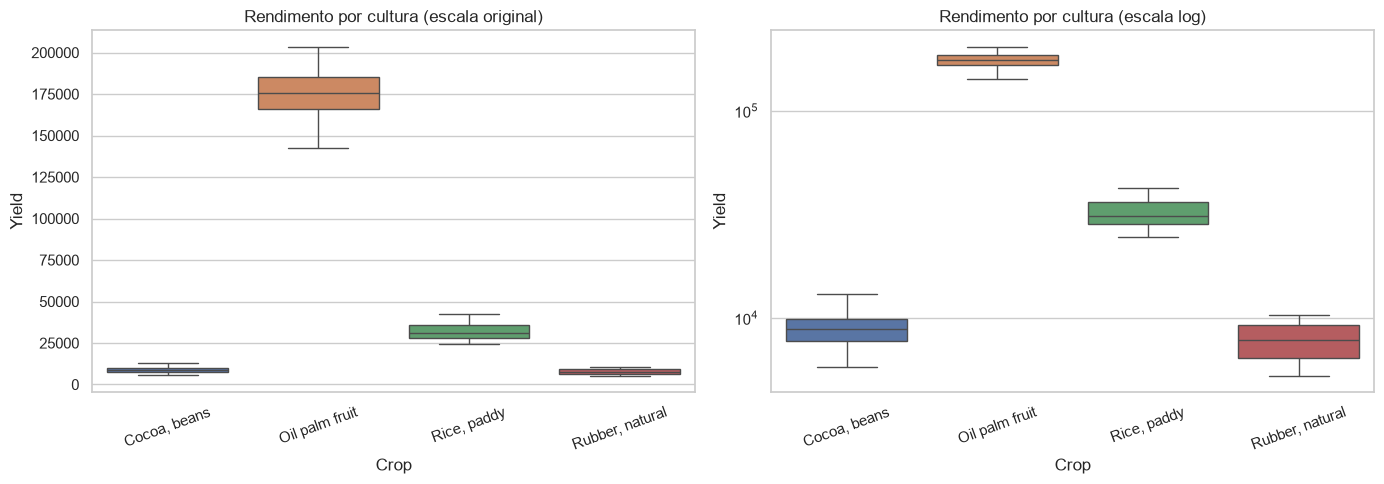

In [7]:
# Comparação do rendimento por cultura
# O boxplot permite comparar a distribuição dos rendimentos
# entre as quatro culturas.

# Cria uma figura com dois gráficos lado a lado.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: escala original
sns.boxplot(
    data=df,
    x="Crop",
    y="Yield",
    ax=axes[0],
    hue="Crop",
    legend=False
)

axes[0].set_title("Rendimento por cultura (escala original)")
axes[0].tick_params(axis="x", rotation=20)

# Gráfico 2: escala logarítmica
# A escala log facilita a comparação porque as culturas
# possuem rendimentos em ordens de grandeza muito diferentes.
sns.boxplot(
    data=df,
    x="Crop",
    y="Yield",
    ax=axes[1],
    hue="Crop",
    legend=False
)

axes[1].set_yscale("log")
axes[1].set_title("Rendimento por cultura (escala log)")
axes[1].tick_params(axis="x", rotation=20)

# Ajusta espaçamentos automaticamente.
plt.tight_layout()

# Salva o gráfico na pasta assets.
plt.savefig("assets/yield_by_crop.png", dpi=120)

# Exibe o gráfico no notebook.
plt.show()


### Diferenças de rendimento entre as culturas

As culturas trabalham em escalas de rendimento muito diferentes. *Oil palm fruit* aparece em uma faixa próxima de 175 mil, *Rice, paddy* fica perto de 32 mil, enquanto *Cocoa, beans* e *Rubber, natural* ficam abaixo de 13 mil.

Essa diferença já indica que o tipo de cultura tem um peso muito grande na previsão do rendimento.


### 3.2 Correlação entre variáveis climáticas e rendimento


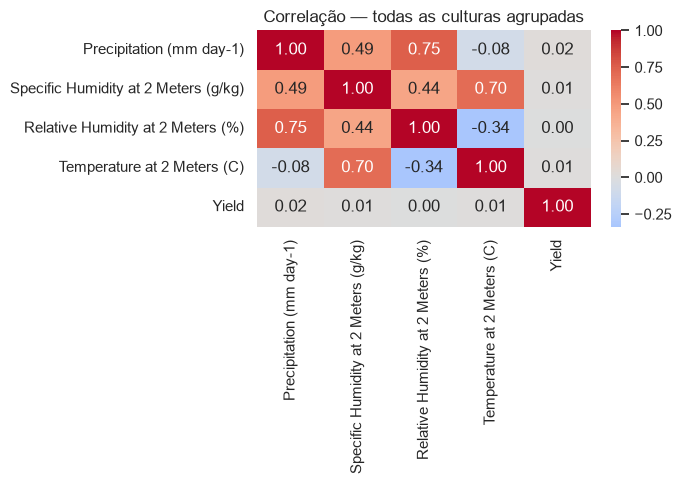

Yield                                   1.000000
Precipitation (mm day-1)                0.018830
Temperature at 2 Meters (C)             0.013007
Specific Humidity at 2 Meters (g/kg)    0.012651
Relative Humidity at 2 Meters (%)       0.000008
Name: Yield, dtype: float64


In [8]:
# Correlação entre as variáveis numéricas
# Correlação mede a relação linear entre duas variáveis.
# +1 = relação positiva forte
# -1 = relação negativa forte
#  0 = pouca ou nenhuma relação linear

# Define as colunas numéricas que serão analisadas.
numeric_cols = [
    "Precipitation (mm day-1)",
    "Specific Humidity at 2 Meters (g/kg)",
    "Relative Humidity at 2 Meters (%)",
    "Temperature at 2 Meters (C)",
    "Yield"
]

# Calcula a matriz de correlação usando todas as culturas juntas.
corr_pooled = df[numeric_cols].corr()

# Cria o mapa de calor da correlação.
plt.figure(figsize=(7, 5))

# annot=True escreve os valores dentro do gráfico.
# center=0 centraliza a escala de cores no zero.
sns.heatmap(
    corr_pooled,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlação — todas as culturas agrupadas")
plt.tight_layout()

# Salva e exibe o gráfico.
plt.savefig("assets/correlacao_pooled.png", dpi=120)
plt.show()

# Mostra apenas as correlações relacionadas ao rendimento,
# da maior para a menor.
print(
    corr_pooled["Yield"].sort_values(ascending=False)
)


### Correlação com todas as culturas juntas

Quando todas as culturas são analisadas no mesmo conjunto, as correlações entre as variáveis climáticas e o rendimento ficam praticamente nulas, todas abaixo de 0,02 em módulo.

Esse resultado é coerente com a estrutura da base: como as mesmas condições climáticas aparecem repetidas entre culturas com rendimentos muito diferentes, a identidade da cultura acaba tendo mais influência na visão geral do que as mudanças do clima.


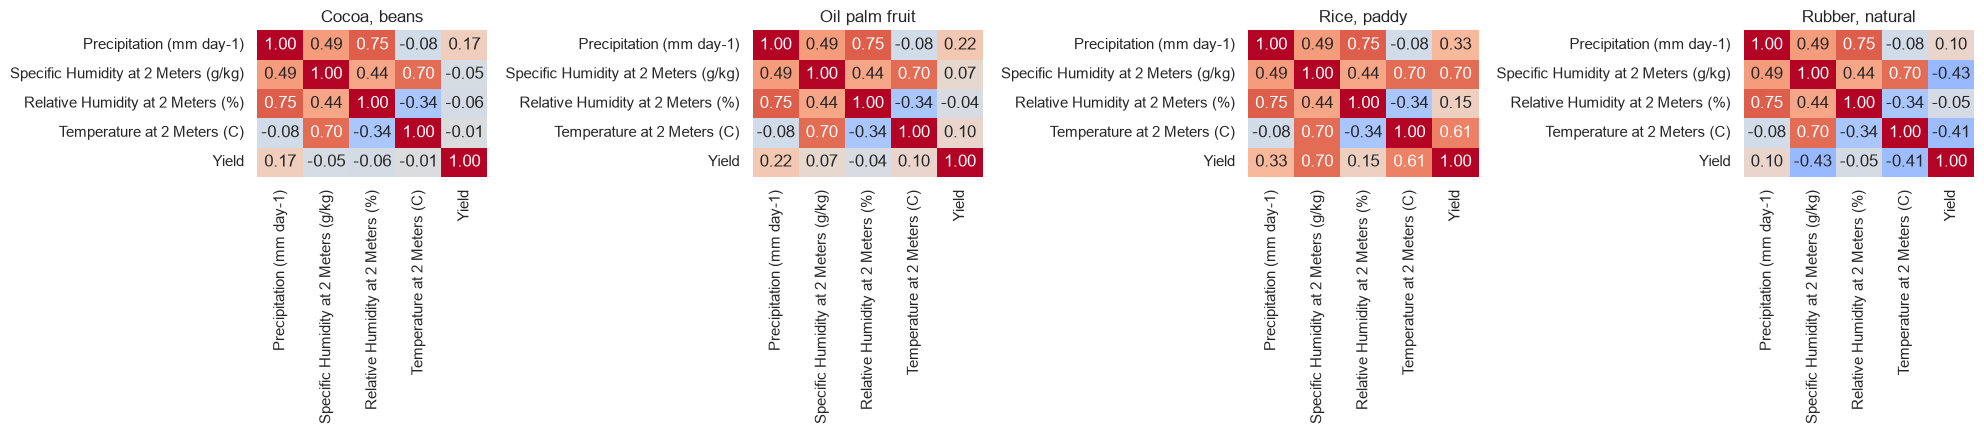

In [9]:
# Correlação analisada separadamente por cultura
# A correlação agregada pode esconder comportamentos específicos.
# Por isso repetimos o cálculo para cada cultura separadamente.

# Cria quatro gráficos lado a lado.
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

# groupby("Crop") percorre a base cultura por cultura.
for ax, (crop, grupo) in zip(axes, df.groupby("Crop")):

    # Calcula a correlação somente dentro da cultura atual.
    corr = grupo[numeric_cols].corr()

    # Desenha a matriz de correlação.
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        ax=ax,
        cbar=False
    )

    # Usa o nome da cultura como título.
    ax.set_title(crop)

plt.tight_layout()

# Salva e exibe o conjunto de gráficos.
plt.savefig("assets/correlacao_por_cultura.png", dpi=120)
plt.show()


### Correlação dentro de cada cultura

A relação muda quando cada cultura é observada separadamente. Em *Rice, paddy*, a umidade específica e a temperatura apresentam correlação positiva forte com o rendimento. Em *Rubber, natural*, essas mesmas variáveis apresentam uma relação negativa moderada ou forte.

Já em *Cocoa, beans* e *Oil palm fruit*, as relações lineares com o clima são mais fracas. Isso sugere que outras informações que não existem na base, como solo, manejo e adubação, também podem ter influência importante no rendimento.


### 3.3 Dispersão: rendimento x variáveis climáticas, por cultura


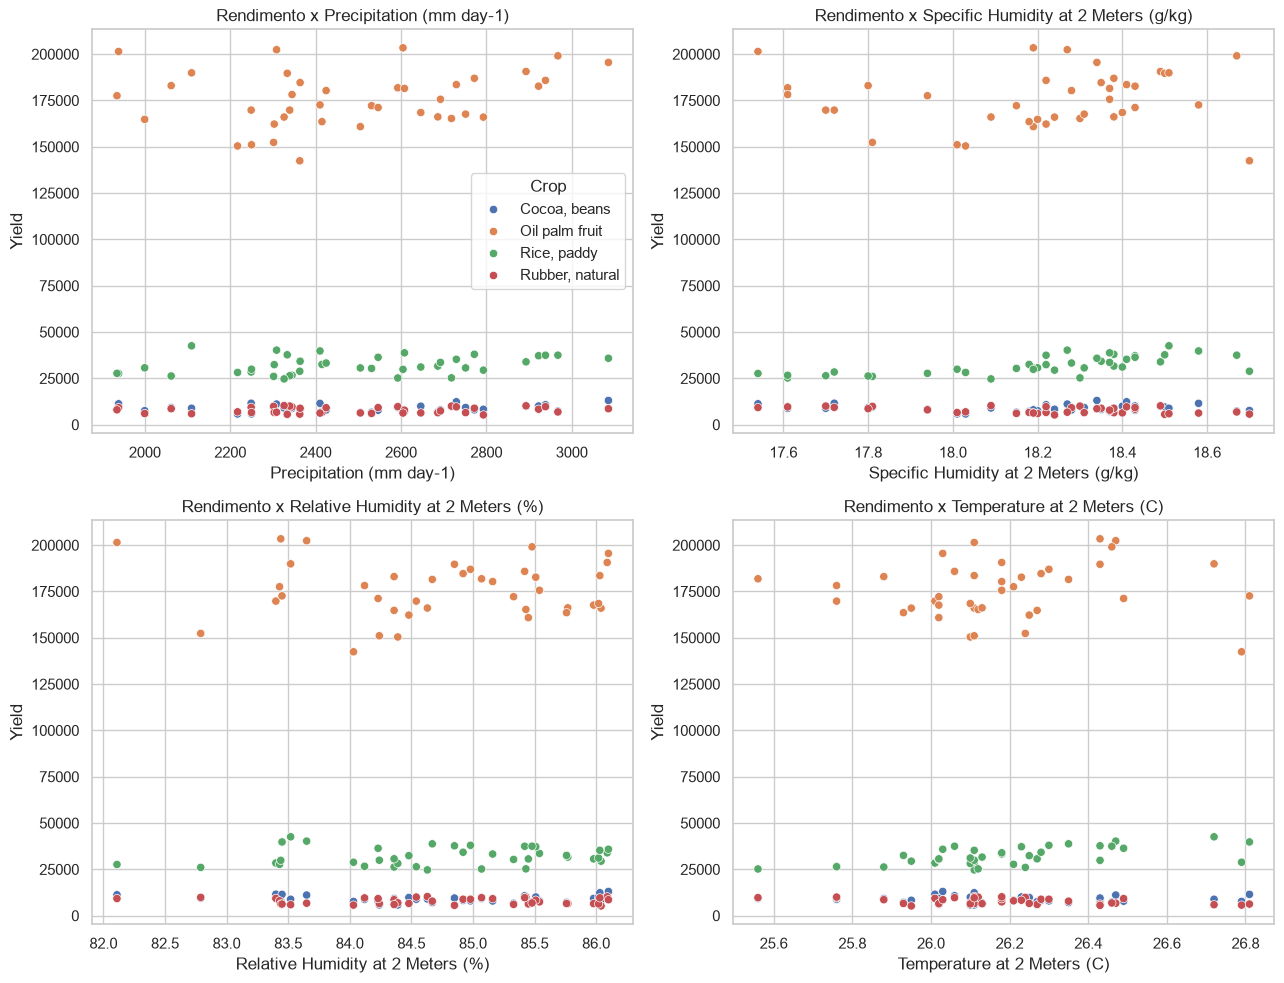

In [10]:
# Relação entre clima e rendimento
# Cada ponto representa um registro.
# Esses gráficos ajudam a enxergar tendências entre o clima e o rendimento.

# Cria uma grade 2 x 2.
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Variáveis climáticas que serão comparadas com Yield.
features = [
    "Precipitation (mm day-1)",
    "Specific Humidity at 2 Meters (g/kg)",
    "Relative Humidity at 2 Meters (%)",
    "Temperature at 2 Meters (C)"
]

# Percorre cada variável e cada posição do gráfico.
for ax, feature in zip(axes.flat, features):

    # hue="Crop" usa cores diferentes para cada cultura.
    sns.scatterplot(
        data=df,
        x=feature,
        y="Yield",
        hue="Crop",
        ax=ax,
        legend=(feature == features[0])
    )

    ax.set_title(f"Rendimento x {feature}")

plt.tight_layout()

# Salva e exibe o gráfico.
plt.savefig("assets/dispersao.png", dpi=120)
plt.show()


## 4. Clusterização, tendências de produtividade e outliers

Nesta etapa usamos K-Means, um algoritmo de aprendizado não supervisionado. Antes da clusterização, as variáveis são padronizadas para que diferenças de unidade e escala não distorçam as distâncias entre os registros.

Testamos diferentes valores de `k` e usamos o método do cotovelo e o coeficiente de silhueta como apoio para escolher a quantidade de grupos.


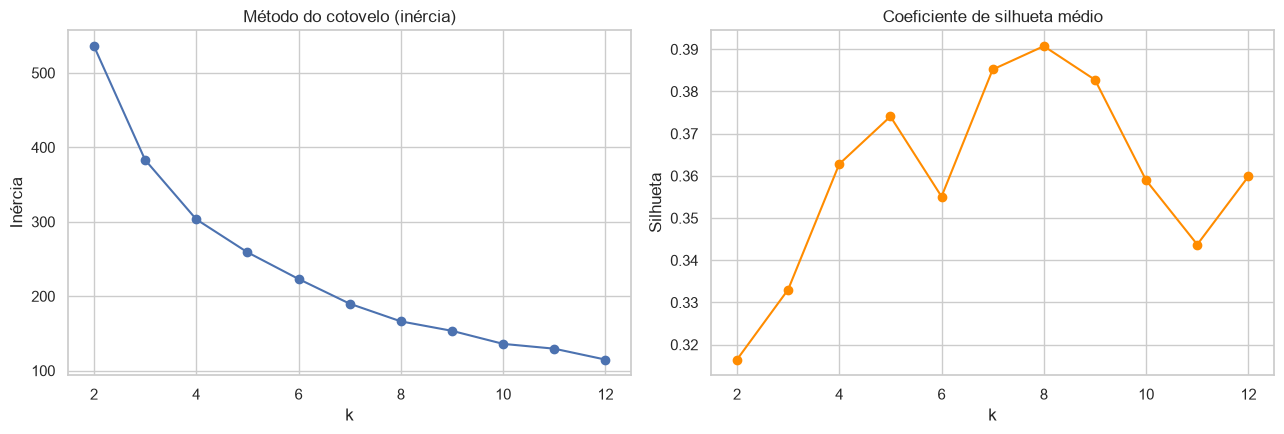

k sugerido pelo coeficiente de silhueta: 8


In [11]:
# Preparação dos dados para o K-Means
# O K-Means usa distâncias entre os registros.
# Como as variáveis possuem escalas diferentes, primeiro padronizamos os dados.

# Para a clusterização usamos clima + rendimento.
features_cluster = numeric_cols

# Cria uma cópia das colunas escolhidas.
X_cluster = df[features_cluster].copy()

# StandardScaler coloca as variáveis em uma escala comparável.
scaler_cluster = StandardScaler()

# fit_transform aprende a escala e aplica a padronização.
X_scaled = scaler_cluster.fit_transform(X_cluster)

# Teste de diferentes valores de k
# Testamos k de 2 a 12 para evitar escolher um valor ótimo
# apenas porque ele estava no limite da busca.

inertias = []
silhouettes = []
k_range = range(2, 13)

for k in k_range:

    # Cria um K-Means com o valor atual de k.
    # n_init=10 testa 10 inicializações e mantém a melhor.
    km = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10
    )

    # Ajusta o modelo e retorna o cluster de cada registro.
    labels = km.fit_predict(X_scaled)

    # Inércia: usada no método do cotovelo.
    inertias.append(km.inertia_)

    # Silhueta: mede a qualidade dos agrupamentos.
    silhouettes.append(
        silhouette_score(X_scaled, labels)
    )

# Método do cotovelo e coeficiente de silhueta
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Método do cotovelo.
axes[0].plot(
    list(k_range),
    inertias,
    marker="o"
)
axes[0].set_title("Método do cotovelo (inércia)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inércia")

# Coeficiente de silhueta.
axes[1].plot(
    list(k_range),
    silhouettes,
    marker="o",
    color="darkorange"
)
axes[1].set_title("Coeficiente de silhueta médio")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhueta")

plt.tight_layout()
plt.savefig("assets/elbow_silhueta.png", dpi=120)
plt.show()

# np.argmax devolve a posição do maior coeficiente de silhueta.
# Depois recuperamos o k correspondente.
melhor_k = list(k_range)[
    int(np.argmax(silhouettes))
]

print(
    f"k sugerido pelo coeficiente de silhueta: {melhor_k}"
)


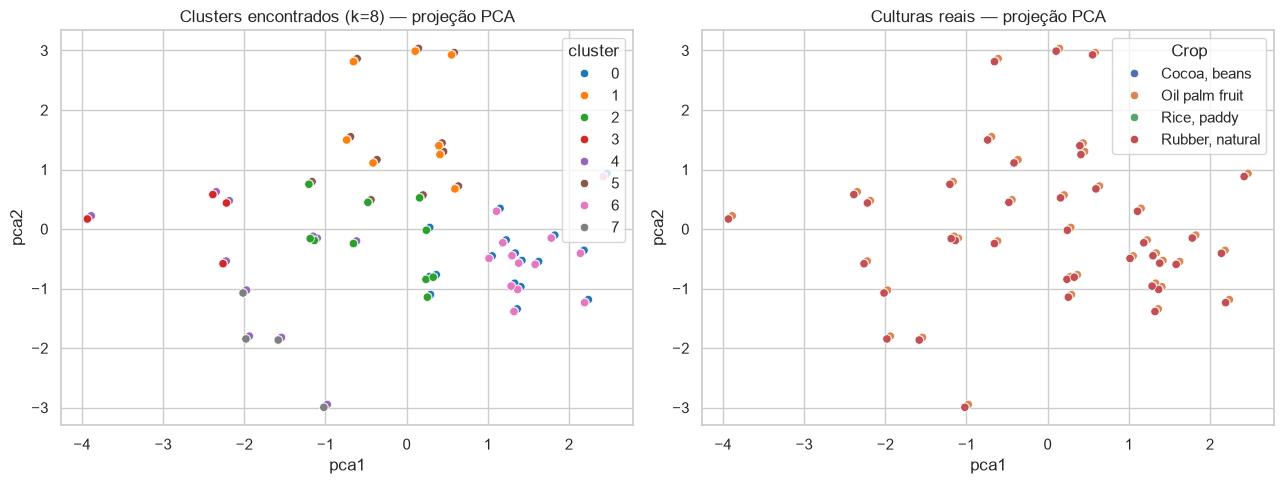

Variância explicada pelos 2 primeiros componentes: 74.8%


In [12]:
# K-Means final
# Usa o melhor k identificado anteriormente para formar os clusters finais.

kmeans_final = KMeans(
    n_clusters=melhor_k,
    random_state=RANDOM_STATE,
    n_init=10
)

# fit_predict aprende os clusters e devolve o cluster de cada linha.
df["cluster"] = kmeans_final.fit_predict(X_scaled)

# PCA para visualizar os clusters em duas dimensões
# O K-Means foi calculado com várias variáveis.
# PCA reduz essas dimensões para duas coordenadas apenas,
# permitindo a visualização em um gráfico 2D.

pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

# Transforma os dados padronizados em duas novas coordenadas.
coords = pca.fit_transform(X_scaled)

# Armazena as coordenadas no DataFrame.
df["pca1"] = coords[:, 0]
df["pca2"] = coords[:, 1]

# Cria dois gráficos lado a lado.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico 1: cores representam os clusters encontrados.
sns.scatterplot(
    data=df,
    x="pca1",
    y="pca2",
    hue="cluster",
    palette="tab10",
    ax=axes[0]
)
axes[0].set_title(
    f"Clusters encontrados (k={melhor_k}) — projeção PCA"
)

# Gráfico 2: cores representam as culturas reais.
# Assim conseguimos comparar clusters encontrados x classes reais.
sns.scatterplot(
    data=df,
    x="pca1",
    y="pca2",
    hue="Crop",
    ax=axes[1]
)
axes[1].set_title(
    "Culturas reais — projeção PCA"
)

plt.tight_layout()
plt.savefig("assets/clusters_pca.png", dpi=120)
plt.show()

# Mostra quanto da informação original foi preservada
# nos dois componentes usados para o gráfico.
print(
    "Variância explicada pelos 2 primeiros componentes: "
    f"{pca.explained_variance_ratio_.sum():.1%}"
)


In [13]:
# Comparação entre clusters e culturas
# A tabela mostra quantos registros de cada cultura
# foram colocados em cada cluster pelo K-Means.
#
# Linhas  = clusters
# Colunas = culturas
pd.crosstab(
    df["cluster"],
    df["Crop"]
)


Crop,"Cocoa, beans",Oil palm fruit,"Rice, paddy","Rubber, natural"
cluster,,,,
0,0,17,0,0
1,8,0,8,8
2,10,0,10,10
3,4,0,4,4
4,0,11,0,0
5,0,11,0,0
6,13,0,13,13
7,4,0,4,4


In [14]:
# Rendimento padronizado por cultura
# Esta análise ajuda a entender por que algumas culturas
# aparecem separadas ou próximas nos clusters.

# Recupera do X_scaled apenas a coluna que corresponde ao Yield.
df["yield_padronizado"] = X_scaled[
    :,
    features_cluster.index("Yield")
]

# Resume a distribuição do rendimento padronizado por cultura.
df.groupby("Crop")["yield_padronizado"].agg(
    ["mean", "std", "min", "max"]
).round(2)


,mean,std,min,max
Crop,,,,
"Cocoa, beans",-0.67,0.02,-0.72,-0.61
Oil palm fruit,1.70,0.21,1.23,2.10
"Rice, paddy",-0.34,0.07,-0.45,-0.19
"Rubber, natural",-0.69,0.02,-0.73,-0.65


### Resultado da clusterização

Ao testar valores de `k` entre 2 e 12, o maior coeficiente de silhueta ocorreu em `k=8`. Os clusters não reproduzem simplesmente as quatro culturas.

O *Oil palm fruit* tende a aparecer mais isolado porque seu rendimento padronizado está em uma faixa bem superior à das outras culturas. Já *Cocoa, beans*, *Rice, paddy* e *Rubber, natural* ficam mais próximas nessa escala e acabam compartilhando clusters.

Como a sequência climática é a mesma para as quatro culturas, o K-Means está capturando principalmente a diferença de magnitude do rendimento e os padrões climáticos compartilhados. Por isso, o resultado deve ser interpretado como uma característica desta base específica, e não como uma regra geral sobre essas culturas.


### 4.1 Identificação de outliers


In [15]:
# Identificação de possíveis outliers com IQR
# IQR = Q3 - Q1
# Limite inferior = Q1 - 1,5 * IQR
# Limite superior = Q3 + 1,5 * IQR
#
# Valores fora desses limites são considerados possíveis outliers.

def marca_outliers_iqr(grupo, coluna="Yield"):

    # Calcula o primeiro e o terceiro quartis.
    q1, q3 = grupo[coluna].quantile([0.25, 0.75])

    # Calcula o intervalo interquartil.
    iqr = q3 - q1

    # Calcula os limites inferior e superior.
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    # Retorna True para registros fora dos limites.
    return (
        (grupo[coluna] < lim_inf)
        | (grupo[coluna] > lim_sup)
    )

# Aplicamos a regra por cultura, porque cada cultura
# possui uma escala de rendimento muito diferente.
df["outlier_iqr"] = (
    df.groupby("Crop", group_keys=False)
      .apply(marca_outliers_iqr)
)

# Conta quantos outliers foram encontrados.
print(
    "Total de outliers identificados "
    f'(regra IQR, por cultura): {df["outlier_iqr"].sum()}'
)

# Exibe apenas as linhas marcadas como outliers.
df.loc[
    df["outlier_iqr"],
    ["Crop"] + numeric_cols + ["cluster"]
]


Total de outliers identificados (regra IQR, por cultura): 0


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield,cluster


### Resultado da busca por outliers

A regra de IQR não identificou outliers de rendimento entre os 156 registros.

Isso não significa que dados agrícolas reais não tenham valores discrepantes. Nesta base, os valores variam de forma relativamente gradual dentro de cada cultura e parecem já estar tratados ou agregados. Em uma coleta direta por sensores de campo, seria mais comum encontrar leituras fora do padrão por falhas de sensor, transmissão ou condições pontuais.


## 5. Modelagem preditiva com cinco algoritmos

A variável `Crop` é categórica e tem grande poder explicativo, então ela entra nos modelos por meio de *one-hot encoding*. As quatro variáveis climáticas são padronizadas.

Separamos os dados em treino e teste mantendo a proporção das culturas. Dentro do conjunto de treino também fazemos validação cruzada com 5 folds. Assim, a comparação entre os modelos não depende apenas de uma única divisão da base.

Os cinco algoritmos avaliados são Regressão Linear, Árvore de Decisão, Random Forest, Gradient Boosting e KNN Regressor.


In [16]:
# Variáveis de entrada e variável que queremos prever
# X contém tudo o que o modelo poderá usar para prever:
# cultura + quatro variáveis climáticas.
X = df[
    ["Crop"] + numeric_cols[:-1]
]

# y é o rendimento que queremos prever.
y = df["Yield"]

# Separação dos dados em treino e teste
# 80% dos dados serão usados para treino.
# 20% ficarão separados para teste.
#
# stratify mantém a proporção das culturas nos dois conjuntos.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=X["Crop"]
)

print(
    f"Treino: {X_train.shape[0]} linhas | "
    f"Teste: {X_test.shape[0]} linhas"
)

# Pré-processamento
# A variável Crop é texto, então precisa virar informação numérica.
# OneHotEncoder cria colunas binárias para as categorias.
#
# As variáveis climáticas são padronizadas com StandardScaler.

preprocessador = ColumnTransformer(
    transformers=[
        (
            "cultura",
            OneHotEncoder(drop="first"),
            ["Crop"]
        ),
        (
            "clima",
            StandardScaler(),
            numeric_cols[:-1]
        )
    ]
)


Treino: 124 linhas | Teste: 32 linhas


In [17]:
# Cinco algoritmos de regressão
modelos = {
    # Modelo linear: aprende relações lineares entre variáveis e rendimento.
    "Regressão Linear": LinearRegression(),

    # Árvore: aprende regras de decisão.
    "Árvore de Decisão": DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        max_depth=5
    ),

    # Random Forest: combina várias árvores para maior estabilidade.
    "Random Forest": RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_estimators=300
    ),

    # Gradient Boosting: constrói modelos sequenciais
    # que tentam corrigir os erros anteriores.
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),

    # KNN: prevê com base nos 5 exemplos mais próximos.
    "KNN Regressor": KNeighborsRegressor(
        n_neighbors=5
    )
}

# Lista que receberá as métricas de cada modelo.
resultados = []

# Validação cruzada com 5 folds
# O treino é dividido em 5 partes.
# Em cada rodada, 4 partes treinam e 1 parte valida.
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Avalia cada um dos cinco modelos.
for nome, modelo in modelos.items():

    # Pipeline une pré-processamento e modelo.
    # Isso evita fazer transformações fora da validação cruzada,
    # reduzindo o risco de vazamento de dados.
    pipe = Pipeline(
        [
            ("prep", preprocessador),
            ("modelo", modelo)
        ]
    )

    # Validação cruzada no conjunto de treino.
    cv_scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=kf,
        scoring=(
            "r2",
            "neg_mean_absolute_error",
            "neg_root_mean_squared_error"
        )
    )

    # Treina com todo o conjunto de treino.
    pipe.fit(X_train, y_train)

    # Faz as previsões no conjunto de teste.
    y_pred = pipe.predict(X_test)

    # Guarda as métricas do modelo atual.
    resultados.append(
        {
            "Modelo": nome,

            # R²: quanto mais próximo de 1, melhor.
            "R² (CV médio)": cv_scores["test_r2"].mean(),

            # O scikit-learn retorna erros negativos internamente.
            # Multiplicamos por -1 para voltar ao valor positivo.
            "MAE (CV médio)": -cv_scores[
                "test_neg_mean_absolute_error"
            ].mean(),

            "RMSE (CV médio)": -cv_scores[
                "test_neg_root_mean_squared_error"
            ].mean(),

            # Métricas no conjunto de teste separado.
            "R² (teste)": r2_score(y_test, y_pred),
            "MAE (teste)": mean_absolute_error(y_test, y_pred),
            "MSE (teste)": mean_squared_error(y_test, y_pred),

            # RMSE = raiz quadrada do MSE.
            "RMSE (teste)": np.sqrt(
                mean_squared_error(y_test, y_pred)
            )
        }
    )

# Transforma os resultados em tabela.
df_resultados = pd.DataFrame(resultados)

# Ordena do maior R² de teste para o menor.
df_resultados = (
    df_resultados
    .sort_values("R² (teste)", ascending=False)
    .reset_index(drop=True)
)

# Exibe a tabela final.
df_resultados


,Modelo,R² (CV médio),MAE (CV médio),RMSE (CV médio),R² (teste),MAE (teste),MSE (teste),RMSE (teste)
0,Regressão Linear,0.986538,5446.527343,8007.332899,0.983985,4988.892022,7.299360e+07,8543.629365
1,Gradient Boosting,0.987060,4741.755309,7626.384040,0.979992,5207.810355,9.119727e+07,9549.725937
2,Random Forest,0.987161,4580.108748,7773.912006,0.979522,4650.142083,9.333655e+07,9661.084381
3,Árvore de Decisão,0.983184,5163.661094,9048.556325,0.967597,6202.771172,1.476900e+08,12152.776207
4,KNN Regressor,0.581623,32213.489267,44286.761339,0.667839,23114.637500,1.513976e+09,38909.839878


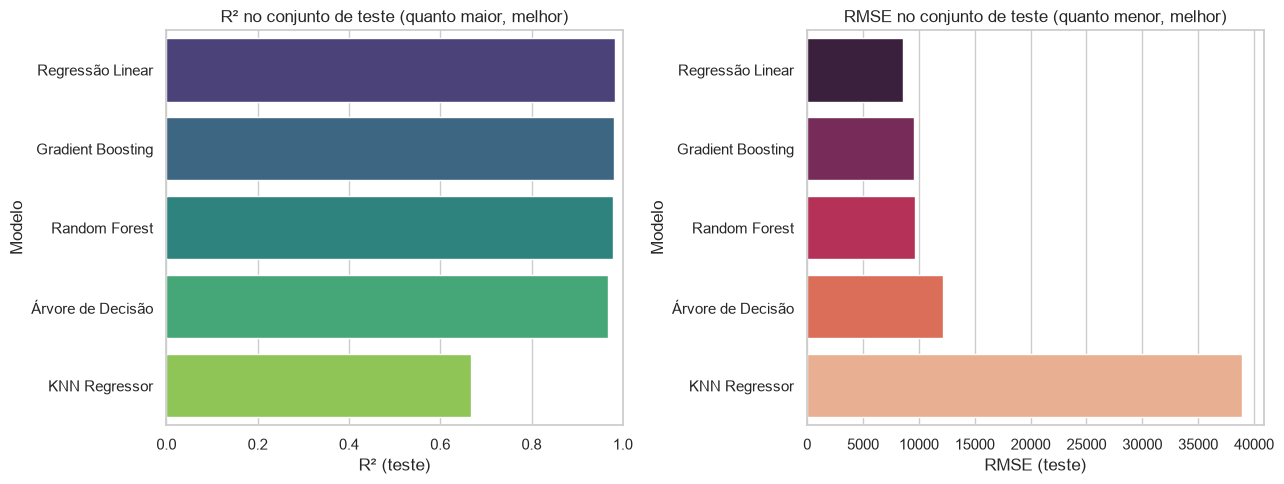

In [18]:
# Comparação visual dos modelos
# No R², valores maiores são melhores. No RMSE, quanto menor o erro, melhor.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico do R².
sns.barplot(
    data=df_resultados,
    x="R² (teste)",
    y="Modelo",
    hue="Modelo",
    ax=axes[0],
    palette="viridis",
    legend=False
)

axes[0].set_title(
    "R² no conjunto de teste (quanto maior, melhor)"
)

axes[0].set_xlim(
    min(
        0,
        df_resultados["R² (teste)"].min() - 0.05
    ),
    1
)

# Gráfico do RMSE.
sns.barplot(
    data=df_resultados,
    x="RMSE (teste)",
    y="Modelo",
    hue="Modelo",
    ax=axes[1],
    palette="rocket",
    legend=False
)

axes[1].set_title(
    "RMSE no conjunto de teste (quanto menor, melhor)"
)

plt.tight_layout()

# Salva e exibe a comparação.
plt.savefig("assets/comparacao_modelos.png", dpi=120)
plt.show()


### 5.1 Comparação com um baseline simples

Os R² dos modelos ficaram altos, mas isso precisa ser interpretado com cuidado. Para ter uma referência, criamos um baseline que não usa nenhuma informação climática. Ele simplesmente prevê, para cada registro do teste, a média de rendimento da respectiva cultura calculada no conjunto de treino.

Essa comparação ajuda a responder uma pergunta importante: os modelos estão realmente aprendendo com o clima ou estão principalmente reconhecendo as diferenças de rendimento entre as culturas?


In [19]:
# Baseline simples para comparação
# O baseline serve como referência mínima.
# Aqui ele ignora completamente o clima e prevê apenas
# a média de rendimento da cultura calculada no treino.

# Média de rendimento de cada cultura no conjunto de treino.
medias_treino = y_train.groupby(
    X_train["Crop"]
).mean()

# Substitui cada cultura do teste pela média correspondente.
pred_baseline = X_test["Crop"].map(
    medias_treino
)

# Métricas do baseline.
r2_baseline = r2_score(
    y_test,
    pred_baseline
)

mae_baseline = mean_absolute_error(
    y_test,
    pred_baseline
)

# Recuperação do melhor modelo treinado
# A tabela foi ordenada por R², então a primeira linha
# representa o modelo com maior R² de teste.
nome_melhor = df_resultados.iloc[0]["Modelo"]
r2_melhor = df_resultados.iloc[0]["R² (teste)"]
mae_melhor = df_resultados.iloc[0]["MAE (teste)"]

# Comparação direta.
print(
    'Baseline "média por cultura" '
    f"— R² (teste): {r2_baseline:.4f} "
    f"| MAE (teste): {mae_baseline:,.0f}"
)

print(
    f"Melhor modelo ({nome_melhor}) "
    f"— R² (teste): {r2_melhor:.4f} "
    f"| MAE (teste): {mae_melhor:,.0f}"
)


Baseline "média por cultura" — R² (teste): 0.9859 | MAE (teste): 4,631
Melhor modelo (Regressão Linear) — R² (teste): 0.9840 | MAE (teste): 4,989


### O que o baseline mostrou

O baseline atingiu um R² de teste muito próximo e, nesta divisão específica, ligeiramente superior ao dos modelos que também usam as variáveis climáticas.

Esse resultado confirma algo que já aparecia na análise exploratória: nesta base, o tipo de cultura concentra grande parte do poder de explicação do rendimento. As variáveis climáticas ainda têm relações relevantes em algumas culturas, principalmente em *Rice, paddy*, mas o ganho adicional delas na previsão geral é pequeno.

Por isso, os R² altos não devem ser lidos isoladamente como prova de que o clima explica quase todo o rendimento.


### 5.2 Real vs. previsto: melhor modelo


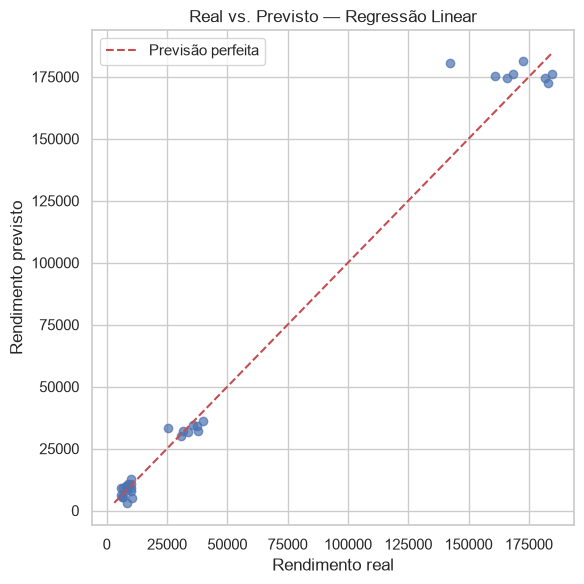

Melhor modelo (por R² no teste): Regressão Linear
Modelo             Regressão Linear
R² (CV médio)              0.986538
MAE (CV médio)          5446.527343
RMSE (CV médio)         8007.332899
R² (teste)                 0.983985
MAE (teste)             4988.892022
MSE (teste)         72993602.720702
RMSE (teste)            8543.629365
Name: 0, dtype: object


In [20]:
# Comparação entre valores reais e previstos
# Aqui comparamos cada valor real do teste
# com a previsão produzida pelo melhor modelo.

# Recupera o nome do melhor modelo.
melhor_nome = df_resultados.iloc[0]["Modelo"]

# Recupera o objeto do modelo correspondente.
melhor_modelo = modelos[melhor_nome]

# Cria o pipeline com o mesmo pré-processamento.
pipe_melhor = Pipeline(
    [
        ("prep", preprocessador),
        ("modelo", melhor_modelo)
    ]
)

# Treina o pipeline.
pipe_melhor.fit(
    X_train,
    y_train
)

# Faz as previsões no teste.
y_pred_melhor = pipe_melhor.predict(
    X_test
)

# Cria o gráfico.
plt.figure(figsize=(6, 6))

# O eixo X mostra o rendimento real e o eixo Y mostra o valor previsto.
plt.scatter(
    y_test,
    y_pred_melhor,
    alpha=0.7
)

# Define os limites dos eixos.
lims = [
    min(
        y_test.min(),
        y_pred_melhor.min()
    ),
    max(
        y_test.max(),
        y_pred_melhor.max()
    )
]

# Linha de previsão perfeita:
# quanto mais próximo dela estiver o ponto, menor o erro.
plt.plot(
    lims,
    lims,
    "r--",
    label="Previsão perfeita"
)

plt.xlabel("Rendimento real")
plt.ylabel("Rendimento previsto")
plt.title(f"Real vs. Previsto — {melhor_nome}")
plt.legend()
plt.tight_layout()

# Salva e exibe o gráfico.
plt.savefig("assets/real_vs_previsto.png", dpi=120)
plt.show()

# Exibe o modelo vencedor e suas métricas.
print(
    f"Melhor modelo (por R² no teste): {melhor_nome}"
)
print(df_resultados.iloc[0])


In [21]:
# Importância das variáveis, quando disponível
# Modelos baseados em árvores costumam disponibilizar
# feature_importances_, que indica o peso relativo das variáveis.
#
# Regressão Linear e KNN não possuem esse atributo.
# Por isso verificamos primeiro se ele existe.

if hasattr(
    pipe_melhor.named_steps["modelo"],
    "feature_importances_"
):

    # Recupera os nomes das variáveis após o pré-processamento.
    nomes_features = (
        pipe_melhor
        .named_steps["prep"]
        .get_feature_names_out()
    )

    # Associa cada nome à sua importância.
    importancias = pd.Series(
        pipe_melhor
        .named_steps["modelo"]
        .feature_importances_,
        index=nomes_features
    ).sort_values(
        ascending=False
    )

    # Cria o gráfico.
    plt.figure(figsize=(8, 5))
    importancias.plot(kind="barh")

    # Coloca a variável mais importante no topo.
    plt.gca().invert_yaxis()

    plt.title(
        f"Importância das variáveis — {melhor_nome}"
    )
    plt.tight_layout()

    # Salva e exibe.
    plt.savefig(
        "assets/importancia_variaveis.png",
        dpi=120
    )
    plt.show()

else:
    # Caso o modelo vencedor não forneça feature_importances_,
    # exibimos uma explicação em vez de gerar erro.
    print(
        "O modelo selecionado não expõe importância de variáveis "
        "diretamente (ex.: Regressão Linear ou KNN). "
        "Nesse caso, os coeficientes/vizinhos substituem essa análise."
    )


O modelo selecionado não expõe importância de variáveis diretamente (ex.: Regressão Linear ou KNN). Nesse caso, os coeficientes/vizinhos substituem essa análise.


## 6. Conclusões

A principal conclusão do trabalho é que a variável `Crop` tem um peso muito grande na explicação do rendimento desta base. As quatro culturas compartilham a mesma sequência de 39 condições climáticas, mas apresentam faixas de rendimento bastante diferentes. Isso explica por que a correlação entre clima e rendimento fica próxima de zero quando todas as culturas são analisadas juntas e também ajuda a entender o comportamento da clusterização.

Quando observamos cada cultura separadamente, o clima passa a mostrar relações diferentes. *Rice, paddy* apresentou relações positivas mais fortes com umidade específica e temperatura, enquanto *Rubber, natural* apresentou relações negativas nessas variáveis. Para *Cocoa, beans* e *Oil palm fruit*, as relações lineares foram mais fracas.

A clusterização com K-Means teve melhor coeficiente de silhueta em `k=8`. O resultado separou principalmente diferenças de magnitude do rendimento, com *Oil palm fruit* mais isolado, em vez de simplesmente reproduzir quatro grupos equivalentes às quatro culturas. A busca de outliers pelo IQR, feita dentro de cada cultura, não encontrou registros discrepantes.

Entre os cinco algoritmos de regressão, a Regressão Linear apresentou o maior R² no conjunto de teste, cerca de 0,984, com MAE próximo de 4.989. Gradient Boosting e Random Forest ficaram muito próximos, com R² em torno de 0,98, enquanto o KNN teve desempenho inferior.

Um ponto importante para interpretar esses números é a comparação com o baseline. Usando apenas a média de rendimento de cada cultura, sem nenhuma variável climática, ele chegou a um R² de aproximadamente 0,986. Isso mostra que boa parte do desempenho dos modelos vem da diferença estrutural entre as culturas e não apenas do efeito do clima.

### Pontos fortes e limitações

Como ponto forte, o projeto usa um pipeline que mantém o pré-processamento junto dos modelos, reduzindo o risco de vazamento de dados. A avaliação combina validação cruzada e um conjunto de teste separado, e todos os modelos são comparados pelas mesmas métricas. A presença de um baseline também ajuda a evitar uma interpretação exagerada do R².

A principal limitação é o tamanho da base: são 156 registros, distribuídos entre apenas quatro culturas. Além disso, as mesmas 39 combinações climáticas se repetem nas quatro culturas. Isso limita a capacidade de avaliar como uma mesma cultura se comportaria em cenários climáticos realmente independentes.

A base também não possui informações de solo, manejo, adubação ou características do talhão. Esses fatores provavelmente ajudariam a explicar parte da variação que o clima sozinho não consegue capturar. Em uma evolução do projeto, seria interessante trabalhar com mais culturas, diferentes regiões e períodos, variáveis agronômicas adicionais e uma separação de treino e teste agrupada por cenário climático.
